<a href="https://colab.research.google.com/github/AntonDozhdikov/Demography_migration/blob/main/%D0%9D%D0%BE%D1%83%D1%82%D0%B1%D1%83%D0%BA_1_%D0%B4%D0%BE%D1%81%D1%82%D1%80%D0%BE%D0%B9%D0%BA%D0%B0_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85_CCM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ноутбук 1 — Заполнение пропусков и когортно-компонентная достройка панелей (1991–2050)

Реалистичный демографический бейзлайн для MARL-эксперимента по 9 регионам Сибирского федерального округа.

## Зачем этот ноутбук
В прошлом эксперименте бейзлайн строился **линейной/полиномиальной экстраполяцией**, а reward агентов
считался **относительно этого же линейного бейзлайна**. В результате:
- агенты «соревновались с прямой линией» → эффекты MADDPG/MATD3 оказались околонулевыми (−0.05%…−0.1%);
- полином экстраполировал СКР Республики Алтай к **нереалистичным 4.06** к 2050;
- знаменатели коэффициентов миграции уходили в околонулевые значения.

## Что делает этот ноутбук
Заменяет простую экстраполяцию **когортно-компонентной моделью (CCM)** — стандартом демографического
прогнозирования (передвижка возрастных когорт с возрастными коэффициентами рождаемости, дожития и миграции).
Это даёт **нелинейную, демографически осмысленную** траекторию, относительно которой у политик появляется
реальное пространство для воздействия.

## Утверждённые параметры
- **Кэп СКР = мягкий 2.5** (допускает исторически высокую рождаемость нац. республик — Тыва, Алтай);
- сохраняется **канон 54 столбца** `ORDERED_COLS` и форма **(60, 54)** на регион;
- **починка near-zero знаменателей** миграции (защита `max(denom, EPS)`);
- **гладкая склейка** факт↔прогноз в точке 2025.

## Выход
- `panel_<регион>.csv` (60×54) для каждого из 9 регионов;
- сводный `panels_all.csv`;
- 9 sanity-плотов (население / СКР / сальдо миграции: факт vs прогноз).

## 1. Константы и якорные демографические профили
ASFR-профили, таблица дожития, стартовая возрастная структура. Это **формы**, нормируемые на СКР и калибруемые на факт — демографические допущения.

In [10]:
# -*- coding: utf-8 -*-
"""
НОУТБУК 1 — Заполнение пропусков + когортно-компонентная достройка панелей 1991–2050
=====================================================================================
Цель: заменить линейную/полиномиальную экстраполяцию более правдоподобной демографически корректной
когортно-компонентной моделью (CCM, cohort-component method), починить артефакты
прошлого прогона, включая аномальные  (СКР Алтая -> 4.06, near-zero знаменатели миграции), сохранить
Сохраняет  54 столбца ORDERED_COLS и форму (60, 54) на регион.

Отличия от первого варианта:
  baseline строился линией -> reward считался относительно линии -> агент
  "соревновался с прямой" -> эффекты MADDPG/MATD3 околонулевые (-0.05%..-0.1%).
  CCM даёт нелинейную, демографически осмысленную траекторию -> у политик
  появляется реальное пространство для воздействия.

Параметры утверждены пользователем:
  - кэп СКР = МЯГКИЙ 2.5 (не жёсткий 2.1) — допускает высокую рождаемость ;
  - сохраняем канон 54 столбца, форму (60,54);
  - починка околонулевых знаменателей миграции.


"""
import math, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.signal import savgol_filter
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from statsmodels.tsa.holtwinters import ExponentialSmoothing
warnings.filterwarnings("ignore")

YEARS = np.arange(1991, 2051)          # целевой горизонт (60 лет)
HIST_END = 2025                        # последний год факта (склейка факт<->прогноз)
TFR_CAP = 2.5                          # МЯГКИЙ кэп реалистичный СКР (
EPS = 1e-9                             # защита знаменателей

# 5-летние возрастные группы для CCM
AGE_GROUPS = [(0,4),(5,9),(10,14),(15,19),(20,24),(25,29),(30,34),(35,39),
              (40,44),(45,49),(50,54),(55,59),(60,64),(65,69),(70,74),
              (75,79),(80,84),(85,200)]
N_AGE = len(AGE_GROUPS)
FERT_IDX = [i for i,(lo,hi) in enumerate(AGE_GROUPS) if lo>=15 and hi<=49]  # 15-19..45-49

# ---------------------------------------------------------------------------
# ЯКОРНЫЕ ДЕМОГРАФИЧЕСКИЕ ПРОФИЛИ (Росстат-типовые, РФ/СФО)
# ---------------------------------------------------------------------------
# Возрастной профиль рождаемости (ASFR-доли по 5-летним группам женщин 15-49).
# Сумма = 1; сдвиг к старшим возрастам со временем (postponement). Источник формы:
# типовые ASFR РФ (пик 25-29). Нормируется на СКР, поэтому это форма, не уровень.
ASFR_SHAPE_1991 = np.array([0.10, 0.34, 0.30, 0.16, 0.07, 0.025, 0.005])  # 15-19..45-49
ASFR_SHAPE_2025 = np.array([0.04, 0.18, 0.33, 0.27, 0.13, 0.045, 0.005])
ASFR_SHAPE_2050 = np.array([0.025,0.13, 0.30, 0.31, 0.17, 0.060, 0.005])

# Базовая таблица дожития: 5-летние вероятности дожития px (РФ-типовые, оба пола усреднённо).
# Калибруется множителем под целевую ожидаемую продолжительность жизни региона.
PX_BASE = np.array([0.997,0.9985,0.9985,0.997,0.994,0.992,0.989,0.985,
                    0.978,0.968,0.952,0.928,0.892,0.835,0.748,0.620,0.450,0.0])

# Стартовая возрастная структура населения РФ-типовая (доли, сумма=1), 1991.
AGE_DIST_1991 = np.array([0.075,0.083,0.090,0.082,0.072,0.078,0.082,0.078,
                          0.060,0.055,0.052,0.050,0.045,0.030,0.030,0.020,0.010,0.008])
AGE_DIST_1991 = AGE_DIST_1991/AGE_DIST_1991.sum()

print("OK: CCM-константы загружены")

OK: CCM-константы загружены


## 2. Базовые помощники
`smooth_clip` (Савицкий-Голей), `enforce_share_sum`, `interp_hist` (заполнение пропусков **только** на истории), `fit_forecast_trend` (вспом. экстраполяция для НЕ-демографических рядов: жильё, кадры, охват ДОУ).

In [11]:
# ---------------------------------------------------------------------------
# СОХРАНЁННЫЕ ИЗ ИСХОДНОГО КОДА ПОМОЩНИКИ (методология не меняется)
# ---------------------------------------------------------------------------
def smooth_clip(arr, low=None, high=None, window=7, poly=2):
    """Сглаживание Савицкого-Голея с интерполяцией и клиппингом (без изменений)."""
    x = np.array(arr, dtype=float)
    m = np.isfinite(x)
    if m.sum() >= max(window, 5):
        w = window if window % 2 == 1 else window + 1
        w = min(w, m.sum() if m.sum() % 2 == 1 else m.sum() - 1)
        if w >= 5:
            xi = pd.Series(x).interpolate(limit_direction="both").to_numpy()
            x = savgol_filter(xi, window_length=w, polyorder=min(poly, w - 2), mode="interp")
    if low is not None:
        x = np.maximum(x, low)
    if high is not None:
        x = np.minimum(x, high)
    return x


def enforce_share_sum(total, *parts):
    """Согласование частей так, чтобы их сумма равнялась total (без изменений)."""
    arrs = [np.maximum(np.array(p, dtype=float), 0) for p in parts]
    s = np.sum(arrs, axis=0)
    s[s == 0] = 1
    arrs = [a / s * total for a in arrs]
    return arrs


def interp_hist(series, start=1991, end=HIST_END, non_negative=True):
    """
    Заполнение ПРОПУСКОВ ТОЛЬКО на историческом отрезке [start, end] интерполяцией
    + Savitzky-Golay. БЕЗ экстраполяции в будущее (это делает CCM).
    Линейный бэккаст только для лет до первого факта.
    """
    s = pd.Series(series).copy()
    s.index = s.index.astype(int)
    s = pd.to_numeric(s, errors="coerce")
    s = s[~s.index.duplicated(keep="last")]
    full = pd.Series(index=np.arange(start, end + 1), dtype=float)
    vi = s.index.intersection(full.index)
    if len(vi):
        full.loc[vi] = s.loc[vi].to_numpy()
    known = full.dropna()
    if len(known) == 0:
        return None  # нет истории — сигнал использовать дефолт
    if len(known) >= 2:
        full.loc[known.index.min():known.index.max()] = (
            full.loc[known.index.min():known.index.max()].interpolate(limit_direction="both"))
        # линейный бэккаст до первого факта
        first = known.index.min()
        if first > start and len(known) >= 2:
            x = known.index.values[:min(len(known),10)].reshape(-1,1)
            y = known.values[:min(len(known),10)].astype(float)
            lin = make_pipeline(PolynomialFeatures(1), LinearRegression()).fit(x,y)
            past = np.arange(start, first)
            full.loc[past] = lin.predict(past.reshape(-1,1))
    full = full.interpolate(limit_direction="both").ffill().bfill()
    out = smooth_clip(full.values.astype(float))
    if non_negative:
        out = np.maximum(out, 0)
    return out


def fit_forecast_trend(series, start=1991, end=2050, non_negative=False, damp=True):
    """
    ВСПОМОГАТЕЛЬНАЯ экстраполяция для НЕ-демографических рядов (жильё, кадры,
    охват ДОУ и т.п.), где CCM неприменима. ETS damped при >=8 точках, иначе полином.
    Население/СКР/миграция через эту функцию НЕ идут — для них работает CCM.
    """
    s = pd.Series(series).astype(float); s.index = s.index.astype(int)
    s = s[~s.index.duplicated(keep="last")]
    full = pd.Series(index=np.arange(start, end+1), dtype=float)
    vi = s.index.intersection(full.index)
    if len(vi): full.loc[vi] = s.loc[vi].to_numpy()
    known = full.dropna()
    if len(known) < 3:
        full = full.interpolate(limit_direction="both").ffill().bfill()
        out = full.values; return np.maximum(out,0) if non_negative else out
    full.loc[known.index.min():known.index.max()] = full.loc[known.index.min():known.index.max()].interpolate(limit_direction="both")
    last = known.index.max(); fut = np.arange(last+1, end+1)
    if len(fut):
        y = known.values.astype(float); preds=None
        if len(y) >= 8:
            try:
                preds = ExponentialSmoothing(y, trend="add", damped_trend=damp).fit(optimized=True).forecast(len(fut))
            except Exception:
                preds=None
        if preds is None:
            deg = 1 if len(y)<10 else 2
            m = make_pipeline(PolynomialFeatures(deg), LinearRegression()).fit(known.index.values.reshape(-1,1), y)
            preds = m.predict(fut.reshape(-1,1))
        full.loc[fut] = preds
    first = known.index.min(); past = np.arange(start, first)
    if len(past):
        m = make_pipeline(PolynomialFeatures(1), LinearRegression()).fit(
            known.index.values[:min(len(known),10)].reshape(-1,1), known.values[:min(len(known),10)].astype(float))
        full.loc[past] = m.predict(past.reshape(-1,1))
    out = smooth_clip(full.interpolate(limit_direction="both").ffill().bfill().values.astype(float))
    return np.maximum(out,0) if non_negative else out

print("OK: помощники (smooth_clip, enforce_share_sum, interp_hist, fit_forecast_trend) загружены")

OK: помощники (smooth_clip, enforce_share_sum, interp_hist, fit_forecast_trend) загружены


## 3. Загрузка регионального файла
Чтение разреженного xlsx/csv, нормализация года и чисел, переименование к каноническим именам (логика сохранена из исходного кода).

In [12]:
# ---------------------------------------------------------------------------
# ЗАГРУЗКА регионального файла (сохранено из исходного кода без изменений логики)
# ---------------------------------------------------------------------------
SRC_RENAME = {
    "Численность постоянного населения на 1 января": "Численность населения всего",
    "Суммарный коэффициент рождаемости (всего)": "СКР (всего)",
    "Суммарный коэффициент рождаемости первых детей": "СКР первых детей",
    "Суммарный коэффициент рождаемости вторых детей": "СКР вторых детей",
    "Суммарный коэффициент рождаемости третьих и последующих детей": "СКР третьих и последующих детей",
    "Число абортов, всего": "Число абортов (всего)",
    "Общая площадь жилых помещений на 1 жителя, кв. м": "Общая площадь жилья на 1 жителя (кв. м)",
    "Валовой коэффициент охвата дошкольным образованием, %": "Валовой коэффициент охвата дошкольным образованием (%)",
    "Численность инвалидов, тыс. человек": "Число инвалидов (тыс.)",
    "Численность врачей, чел.": "Численность врачей",
    "Число больничных коек, ед.": "Число больничных коек",
    "Обеспеченность больничными койками (на 10 тыс. населения)": "Обеспеченность койками (на 10 тыс.)",
}

def load_region_file(path: str, sheet="statespace"):
    path = str(path)
    if path.lower().endswith(".csv"):
        try:
            df = pd.read_csv(path, sep=";")
            if df.shape[1] == 1: df = pd.read_csv(path)
        except Exception:
            df = pd.read_csv(path)
    else:
        try: df = pd.read_excel(path, sheet_name=sheet)
        except Exception: df = pd.read_excel(path)
    df.columns = [str(c).strip() for c in df.columns]
    region = None
    for rc in ["Регион","регион","Region"]:
        if rc in df.columns:
            vals = df[rc].dropna().astype(str)
            if len(vals): region = vals.iloc[0].strip()
            break
    if region is None: region = Path(path).stem
    year_col = next((c for c in ["Год","год","year","Year"] if c in df.columns), None)
    if year_col is None:
        raise ValueError(f"{region}: не найдена колонка года. Колонки: {list(df.columns)}")
    df = df.rename(columns={year_col:"Год"})
    for c in df.columns:
        if c in ("Регион","регион","Region","Тип","type"): continue
        if df[c].dtype == object:
            df[c] = (df[c].astype(str).str.replace("\u00a0","",regex=False)
                     .str.replace(" ","",regex=False).str.replace(",",".",regex=False)
                     .replace({"":np.nan,"nan":np.nan,"None":np.nan}))
        df[c] = pd.to_numeric(df[c], errors="coerce") if c != "Год" else df[c]
    df["Год"] = pd.to_numeric(df["Год"], errors="coerce")
    df = df.dropna(subset=["Год"]).copy()
    df["Год"] = df["Год"].astype(int)
    df = df.sort_values("Год").drop_duplicates(subset=["Год"], keep="last").reset_index(drop=True)
    df = df.rename(columns=SRC_RENAME)
    drop_cols = [c for c in ["Регион","регион","Region","Тип","type"] if c in df.columns]
    df = df.drop(columns=drop_cols, errors="ignore")
    df = df.set_index("Год")
    return df, region

def _series(df, col):
    return df[col] if col in df.columns else pd.Series(dtype=float)

print("OK: load_region_file загружен")

OK: load_region_file загружен


## 4. Ядро CCM: когортно-компонентная проекция
**5-летний шаг** передвижки когорт (корректно: за год нельзя состарить группу на целые 5 лет), затем интерполяция узлов к годовым рядам.

Уравнение передвижки для группы a, шага t:
$$P_{a+1,t+1} = P_{a,t}\cdot s_a(t) + \tfrac{1}{2}M_a(t)$$
$$P_{0,t+1} = B(t)\cdot s_0(t) + \tfrac{1}{2}M_0(t),\quad B(t)=\text{СКР}(t)\sum_a \text{ASFR}_a(t)\,W_a(t)$$

In [13]:
# ---------------------------------------------------------------------------
# ЯДРО CCM: когортно-компонентная проекция населения 1991->2050
# ---------------------------------------------------------------------------
def _asfr_shape(year):
    """Линейная интерполяция формы ASFR между 1991/2025/2050 профилями."""
    if year <= 1991: return ASFR_SHAPE_1991.copy()
    if year >= 2050: return ASFR_SHAPE_2050.copy()
    if year <= 2025:
        w = (year-1991)/(2025-1991); base = (1-w)*ASFR_SHAPE_1991 + w*ASFR_SHAPE_2025
    else:
        w = (year-2025)/(2050-2025); base = (1-w)*ASFR_SHAPE_2025 + w*ASFR_SHAPE_2050
    return base/base.sum()

def cohort_component_projection(tfr_path, e0_target, net_mig_path,
                                pop0, female_share0=0.535, age_dist0=None):
    """
    Когортно-компонентная проекция по 5-летним группам, годовой шаг (с интерполяцией
    5-летних px к годовым через px**(1/5)).

    Уравнение передвижки (для каждой возр. группы a, года t):
        P[a+1, t+1] = P[a, t] * s_a(t) + 0.5*NetMig_a(t)            (старение)
        P[0,   t+1] = Births(t) * s_birth(t) + 0.5*NetMig_0(t)      (новорождённые)
    Рождения:
        Births(t) = СКР(t) * sum_a( ASFR_share_a(t) * W_a(t) ) / 5
    где W_a — численность женщин в фертильной группе a.

    Параметры:
        tfr_path     : np.array СКР по годам (1991..2050), уже с кэпом 2.5
        e0_target    : целевая ожидаемая продолжительность жизни 2050 (для калибровки px)
        net_mig_path : np.array чистого миграционного сальдо по годам
        pop0         : стартовое население 1991
    Возвращает:
        dict с годовыми рядами: pop, women_15_49, men_15_49, children(<репр),
        older(>репр), births, deaths, net_natural, age_matrix (годовая, для отладки)
    """
    nyears = len(YEARS)
    if age_dist0 is None: age_dist0 = AGE_DIST_1991
    # начальная популяция по 5-летним возрастным группам и полу
    pop_a = pop0 * age_dist0.copy()
    female_a = pop_a * female_share0
    male_a   = pop_a * (1 - female_share0)

    out = {k: np.zeros(nyears) for k in
           ["pop","women_15_49","men_15_49","children","older","births","deaths","net_natural"]}
    age_hist = np.zeros((nyears, N_AGE))

    # ВАЖНО: CCM работает 5-летними шагами (корректная передвижка когорт),
    # затем 5-летние узлы интерполируются к годовым рядам. Это устраняет
    # «телескопирование» (когда годовой сдвиг на целую 5-летнюю группу
    # старит население в 5 раз быстрее реальности).
    step_years = list(range(1991, 2051, 5)) + [2050]
    step_years = sorted(set(step_years))
    node = {k: [] for k in out}; node_year = []

    def record(yr, fem, mal, births5):
        total = fem.sum() + mal.sum()
        women_fert = fem[FERT_IDX].sum()
        last_fert = max(FERT_IDX)
        node_year.append(yr)
        node["pop"].append(total)
        node["women_15_49"].append(women_fert)
        node["men_15_49"].append(mal[FERT_IDX].sum())
        node["children"].append(fem[:3].sum() + mal[:3].sum())
        node["older"].append(fem[last_fert+1:].sum() + mal[last_fert+1:].sum())
        node["births"].append(births5 / 5.0)   # годовой эквивалент

    # сальдо миграции и СКР агрегируем по 5-летнему интервалу
    def interval_tfr(y0):
        idx = [i for i,y in enumerate(YEARS) if y0 <= y < y0+5]
        return float(np.mean(tfr_path[idx])) if idx else float(tfr_path[-1])
    def interval_mig(y0):
        idx = [i for i,y in enumerate(YEARS) if y0 <= y < y0+5]
        return float(np.sum(net_mig_path[idx])) if idx else 0.0

    mig_profile = np.zeros(N_AGE)
    mig_profile[3:9] = [0.10,0.22,0.24,0.18,0.13,0.08]
    mig_profile[:3] = 0.05/3
    mig_profile = mig_profile / mig_profile.sum()

    record(1991, female_a, male_a, 0.0)
    cur_year = 1991
    while cur_year < 2050:
        y0 = cur_year
        # --- 5-летние вероятности дожития, тренд к e0_target ---
        improve = np.interp(y0, [1991, 2025, 2050],
                            [1.04, 1.00, max(0.85, 1.0-(e0_target-72)/200)])
        qx = np.clip((1 - PX_BASE) * improve, 0, 0.95)
        px5 = 1 - qx                                  # 5-летнее дожитие группы

        women_fert = female_a[FERT_IDX]
        tfr = interval_tfr(y0)
        shape = _asfr_shape(y0)
        # рождения за 5 лет: СКР * (сумма по фертильным группам женщин) ;
        # СКР уже в детях на женщину за весь репродуктивный период -> делим на число
        # фертильных групп (7) и умножаем на 5 лет проживания в каждой группе.
        births5 = tfr * np.sum(shape * women_fert) * (5.0/7.0)
        births5 = max(births5, 0)

        nm5 = interval_mig(y0)
        net_mig_a = nm5 * mig_profile

        # передвижка когорт на 5 лет: группа a -> a+1
        new_f = np.zeros(N_AGE); new_m = np.zeros(N_AGE)
        for a in range(N_AGE-1, 0, -1):
            new_f[a] = female_a[a-1]*px5[a-1] + 0.5*net_mig_a[a]*female_share0
            new_m[a] = male_a[a-1]*px5[a-1]   + 0.5*net_mig_a[a]*(1-female_share0)
        new_f[-1] += female_a[-1]*px5[-1]
        new_m[-1] += male_a[-1]*px5[-1]
        new_f[0] = births5*0.487*px5[0] + 0.5*net_mig_a[0]*female_share0
        new_m[0] = births5*0.513*px5[0] + 0.5*net_mig_a[0]*(1-female_share0)

        deaths5 = (female_a.sum()+male_a.sum()) - (new_f.sum()+new_m.sum()) + births5 + nm5
        female_a, male_a = np.maximum(new_f,0), np.maximum(new_m,0)
        cur_year = min(y0+5, 2050)
        record(cur_year, female_a, male_a, births5)
        # запишем смерти как годовой эквивалент в узел (привяжем ниже)
        node.setdefault("deaths5", []).append(max(deaths5,0)/5.0)

    # --- интерполяция 5-летних узлов к годовым рядам YEARS ---
    nyear_arr = np.array(node_year, dtype=float)
    for k in ["pop","women_15_49","men_15_49","children","older","births"]:
        out[k] = np.interp(YEARS, nyear_arr, np.array(node[k]))
    # смерти: узлы deaths5 относятся к интервалам между узлами -> привяжем к серединам
    if node.get("deaths5"):
        mid = (nyear_arr[:-1]+nyear_arr[1:])/2
        out["deaths"] = np.interp(YEARS, mid, np.array(node["deaths5"]))
    out["net_natural"] = out["births"] - out["deaths"]
    return out, age_hist

print("OK: cohort_component_projection загружен")

OK: cohort_component_projection загружен


## 5. Сборка state-space: CCM-население + фиксы артефактов
`_tfr_with_cap` (кэп 2.5, тренд к демографически осмысленному таргету — **делает артефакт типа 4.06 невозможным**), `_netmig_path` (затухание к 0), калибровка уровня CCM на факт, гладкая склейка.

In [14]:
# ---------------------------------------------------------------------------
# СБОРКА state-space: CCM-население + фиксы артефактов + перенос реальных рядов
# ---------------------------------------------------------------------------
def _tfr_with_cap(df):
    """
    СКР: интерполируем историю, тренд к региональному таргету, кэп 2.5 (МЯГКИЙ).
    ФИКС АРТЕФАКТА: прошлый полином экстраполировал Алтай к 4.06 — здесь невозможно,
    т.к. (1) тренд строится к демографически осмысленному таргету, (2) clip<=2.5.
    """
    tfr_hist = interp_hist(_series(df, "СКР (всего)"), non_negative=True)
    if tfr_hist is None:
        tfr_hist = np.full(HIST_END-1991+1, 1.5)
    # последнее наблюдение как старт прогноза
    last_val = float(tfr_hist[-1])
    # региональный таргет 2050: к последнему значению лёгкий дрейф к 1.5-1.7, но не выше кэпа
    target_2050 = np.clip(0.6*last_val + 0.4*1.6, 1.1, TFR_CAP)
    fut_years = np.arange(HIST_END+1, 2051)
    fut = np.linspace(last_val, target_2050, len(fut_years))
    tfr_full = np.concatenate([tfr_hist, fut])
    tfr_full = np.clip(tfr_full, 0.7, TFR_CAP)   # МЯГКИЙ кэп 2.5
    return smooth_clip(tfr_full, low=0.7, high=TFR_CAP)

def _netmig_path(df, pop_hint):
    """
    Чистое миграционное сальдо: история + затухающий тренд.
    ФИКС near-zero знаменателей: при расчёте коэффициентов знаменатель защищён max(.,EPS).
    """
    mig_src = _series(df, "Миграционное сальдо")
    if len(mig_src.dropna()) >= 2:
        mig_hist = interp_hist(mig_src, non_negative=False)
        last = float(mig_hist[-1])
        fut_years = np.arange(HIST_END+1, 2051)
        fut = last * np.exp(-0.02*np.arange(1,len(fut_years)+1))  # затухание к 0
        return np.concatenate([mig_hist, fut])
    # нет данных миграции -> малое сальдо пропорц. населению
    return np.zeros(len(YEARS))

def build_state_space_ccm(region_file, sheet="statespace"):
    df, region = load_region_file(region_file, sheet=sheet)
    base = pd.DataFrame({"Год": YEARS})
    t = np.arange(len(base))

    # --- стартовые величины для CCM ---
    pop_hist = interp_hist(_series(df, "Численность населения всего"), non_negative=True)
    if pop_hist is None or pop_hist[0] <= 0:
        # если нет факта 1991 — берём первый доступный
        pop_hist = np.full(HIST_END-1991+1, 1.0e6)
    pop0 = float(pop_hist[0])

    tfr_path = _tfr_with_cap(df)
    net_mig  = _netmig_path(df, pop0)

    # целевая e0 2050 — выше для более урбанизированных
    urb = _series(df, "Доля городского населения в общей численности населения на 1 января")
    urb_mean = float(np.nanmean(urb.values)) if len(urb.dropna()) else 60.0
    e0_target = np.interp(urb_mean, [40, 60, 80], [76, 78, 80])

    # --- ЗАПУСК CCM ---
    ccm, age_hist = cohort_component_projection(tfr_path, e0_target, net_mig, pop0)

    # КАЛИБРОВКА уровня CCM на исторический факт населения (множитель по перекрытию)
    hist_years = np.arange(1991, HIST_END+1)
    ccm_pop_hist = ccm["pop"][:len(hist_years)]
    if pop_hist is not None and np.nanmean(ccm_pop_hist) > 0:
        scale = np.nanmean(pop_hist) / np.nanmean(ccm_pop_hist)
        for k in ["pop","women_15_49","men_15_49","children","older","births","deaths","net_natural"]:
            ccm[k] = ccm[k]*scale
    # гладкая склейка факт<->CCM в точке HIST_END
    pop_full = ccm["pop"].copy()
    # заменяем исторический отрезок реальным фактом там, где он есть
    pop_full[:len(pop_hist)] = np.where(np.isfinite(pop_hist), pop_hist, pop_full[:len(pop_hist)])
    pop_full = smooth_clip(pop_full, low=1000)

    base["Численность населения всего"] = pop_full
    base["СКР (всего)"] = tfr_path
    base["Миграционное сальдо"] = net_mig
    base["Абсолютное число рождений"] = smooth_clip(ccm["births"], low=50)

    pop = base["Численность населения всего"].to_numpy()
    base.attrs.update(dict(region=region, t=t, pop=pop, ccm=ccm, e0_target=e0_target,
                           df=df, women=ccm["women_15_49"], men=ccm["men_15_49"],
                           children=ccm["children"], older=ccm["older"]))
    return base, region

print("OK: build_state_space_ccm загружен")

OK: build_state_space_ccm загружен


## 6. Производные индикаторы
Возрастно-половая структура **напрямую из CCM** (а не из синус-якорей), балансы рождаемости/смертности, миграция по возрастам, СКР по очерёдности, брачность, аборты/ЭКО, жильё, образование, мед. ресурсы. Знаменатели защищены `max(·, EPS)`.

In [15]:
# ---------------------------------------------------------------------------
# Производные индикаторы: возрастная структура из CCM + балансы + переносы
# ---------------------------------------------------------------------------
def add_derived_ccm(base, region_file, sheet="statespace"):
    df, _ = load_region_file(region_file, sheet=sheet)
    t = base.attrs["t"]; pop = base.attrs["pop"]; ccm = base.attrs["ccm"]
    sc = float(np.nanmean(pop)) / 1.1e6   # масштаб относительно эталонного Курска

    # --- возрастно-половая структура НАПРЯМУЮ из CCM (не из синус-якорей!) ---
    women_fert = ccm["women_15_49"]; men_fert = ccm["men_15_49"]
    children = ccm["children"]; older = ccm["older"]
    women_total = women_fert + children*0.487 + older*0.55   # грубая оценка всех женщин
    women_total = np.clip(women_total, women_fert, pop*0.56)
    children, women_fert, men_fert, older = enforce_share_sum(pop, children, women_fert, men_fert, older)

    base["Численность женщин 15-49 лет"] = women_fert
    base["Доля женщин 15-49 лет в общей численности женщин"] = women_fert / np.maximum(women_total, EPS) * 100
    base["Численность мужчин 15-49 лет"] = men_fert
    base["Соотношение мужчин и женщин 15-49 лет (мужчин на 1 женщину)"] = men_fert / np.maximum(women_fert, EPS)
    base["Численность населения моложе репродуктивного возраста"] = children
    base["Численность населения старше репродуктивного возраста"] = older

    def sundberg(child, old, pop):
        cs = child/np.maximum(pop,EPS); os_=old/np.maximum(pop,EPS); out=[]
        for a,b in zip(cs,os_):
            if a>0.24 and b<0.18: out.append("прогрессивный")
            elif 0.18<=a<=0.24 and 0.18<=b<=0.27: out.append("стационарный")
            else: out.append("регрессивный")
        return out
    base["Тип половозрастной структуры (Сундберг)"] = sundberg(children, older, pop)

    # --- балансы рождаемости/смертности ИЗ CCM ---
    births = base["Абсолютное число рождений"].to_numpy()
    avg_pop = (pop + np.roll(pop,1)); avg_pop[0]=pop[0]; avg_pop=avg_pop/2
    deaths = smooth_clip(ccm["deaths"], low=births*0.5)
    base["Коэффициент естественного прироста (на 1000)"] = (births - deaths) / np.maximum(avg_pop,EPS) * 1000
    # ФИКС near-zero знаменателя миграции: max(avg_pop, EPS)
    base["Коэффициент миграционного прироста (на 10000)"] = base["Миграционное сальдо"].to_numpy() / np.maximum(avg_pop,EPS) * 10000

    # --- миграция по возрастным группам ---
    mig = base["Миграционное сальдо"].to_numpy()
    child_mig = np.interp(base["Год"], [1991,2005,2020,2050],[0.16,0.14,0.18,0.17])
    old_mig   = np.interp(base["Год"], [1991,2005,2020,2050],[0.08,0.07,0.09,0.10])
    work_mig  = 1-child_mig-old_mig
    base["Численность мигрантов моложе трудоспособного возраста (сальдо)"] = mig*child_mig
    base["Численность мигрантов трудоспособного возраста (сальдо)"] = mig*work_mig
    base["Численность мигрантов старше трудоспособного возраста (сальдо)"] = mig*old_mig

    # --- СКР по очерёдности: перенос факта или согласование ---
    for c in ["СКР первых детей","СКР вторых детей","СКР третьих и последующих детей"]:
        s = _series(df, c)
        base[c] = interp_hist(s, end=2050, non_negative=True) if len(s.dropna())>=2 else np.nan
        if base[c].isna().all() if hasattr(base[c],'isna') else np.all(np.isnan(base[c])):
            base[c] = np.nan
    par = base[["СКР первых детей","СКР вторых детей","СКР третьих и последующих детей"]].sum(axis=1)
    bad = par.isna() | (par < 0.7*base["СКР (всего)"]) | (par > 1.3*base["СКР (всего)"])
    fs = np.interp(base["Год"],[1991,2005,2024,2050],[0.54,0.50,0.41,0.40])
    ss = np.interp(base["Год"],[1991,2005,2024,2050],[0.31,0.34,0.34,0.35]); ts=1-fs-ss
    base.loc[bad,"СКР первых детей"]=base.loc[bad,"СКР (всего)"]*fs[bad.to_numpy()]
    base.loc[bad,"СКР вторых детей"]=base.loc[bad,"СКР (всего)"]*ss[bad.to_numpy()]
    base.loc[bad,"СКР третьих и последующих детей"]=base.loc[bad,"СКР (всего)"]*ts[bad.to_numpy()]

    # --- брачность/разводимость (типовые формы РФ) ---
    wave = 1+0.06*np.exp(-((base["Год"]-2014)/6)**2)-0.05*np.exp(-((base["Год"]-2020)/3.5)**2)
    mar = np.interp(base["Год"],[1991,2000,2011,2020,2035,2050],[8.9,6.2,9.2,6.5,6.0,5.8])*wave
    div = np.interp(base["Год"],[1991,2000,2011,2020,2035,2050],[3.8,4.3,4.7,4.2,4.0,3.9])
    base["Коэффициент брачности (на 1000)"]=np.clip(mar,3.0,12.0)
    base["Коэффициент разводимости (на 1000)"]=np.clip(div,1.5,6.5)
    base["Отношение числа браков к числу разводов"]=base["Коэффициент брачности (на 1000)"]/np.maximum(base["Коэффициент разводимости (на 1000)"],EPS)
    base["Доля рождений в браке"]=np.clip(np.interp(base["Год"],[1991,2000,2010,2020,2035,2050],[72,68,70,73,74,74])+1.5*np.sin(t/6),60,85)
    base["Доля рождений вне брака"]=100-base["Доля рождений в браке"]
    base["Средний возраст матери при рождении ребёнка"]=np.interp(base["Год"],[1991,2000,2010,2020,2035,2050],[24.2,25.1,27.2,28.7,29.5,29.8])+0.12*np.sin(t/4)

    # --- аборты/бесплодие/ЭКО ---
    ab_src=_series(df,"Число абортов (всего)")
    if len(ab_src.dropna())>=2: base["Число абортов (всего)"]=fit_forecast_trend(ab_src,non_negative=True)
    else: base["Число абортов (всего)"]=smooth_clip(births*np.interp(base["Год"],[1991,2000,2010,2020,2035,2050],[180,120,65,45,32,25])/100,low=10)
    ab=base["Число абортов (всего)"].to_numpy()
    base["Число абортов на 1000 женщин 15-49 лет"]=ab/np.maximum(women_fert,EPS)*1000
    base["Число абортов на 100 родов"]=ab/np.maximum(births,EPS)*100
    base["Число женщин с бесплодием"]=smooth_clip(np.interp(base["Год"],[1991,2000,2010,2020,2035,2050],[1800,2200,3000,3600,3900,4100])*sc+80*np.sin(t/5),low=50)
    base["Число мужчин с бесплодием"]=smooth_clip(np.interp(base["Год"],[1991,2000,2010,2020,2035,2050],[900,1200,1800,2200,2400,2500])*sc+55*np.sin(t/5.3),low=30)
    base["Число циклов ЭКО"]=smooth_clip(np.interp(base["Год"],[1991,2000,2005,2010,2020,2035,2050],[0,5,40,120,320,430,480])*sc+8*np.sin(t/3),low=0)
    base["Число родов после ЭКО"]=base["Число циклов ЭКО"]*np.interp(base["Год"],[1991,2005,2020,2050],[0.0,0.22,0.28,0.30])
    base["Число детей, рождённых после ЭКО"]=base["Число родов после ЭКО"]*np.interp(base["Год"],[1991,2005,2020,2050],[1.00,1.08,1.11,1.10])

    # --- кадры/жильё/образование ---
    base["Укомплектованность педиатрами (%)"]=np.clip(np.interp(base["Год"],[1991,2000,2010,2020,2035,2050],[84,80,82,79,81,82])+2*np.sin(t/4),65,95)
    base["Укомплектованность акушерами-гинекологами (%)"]=np.clip(np.interp(base["Год"],[1991,2000,2010,2020,2035,2050],[88,85,87,83,84,85])+1.5*np.sin(t/5),70,98)
    base["Укомплектованность неонатологами (%)"]=np.clip(np.interp(base["Год"],[1991,2000,2010,2020,2035,2050],[82,78,80,77,79,80])+1.8*np.sin(t/4.5),65,95)
    hs=_series(df,"Общая площадь жилья на 1 жителя (кв. м)")
    base["Общая площадь жилья на 1 жителя (кв. м)"]=fit_forecast_trend(hs,non_negative=True) if len(hs.dropna())>=2 else np.interp(base["Год"],[1991,2000,2010,2020,2035,2050],[18.5,22.0,26.5,31.5,36.5,40.0])
    base["Площадь благоустроенного жилья на 1 жителя (кв. м)"]=base["Общая площадь жилья на 1 жителя (кв. м)"]*np.interp(base["Год"],[1991,2000,2010,2020,2035,2050],[0.58,0.63,0.70,0.76,0.81,0.84])
    base["Доля благоустроенного жилья в общей площади (%)"]=base["Площадь благоустроенного жилья на 1 жителя (кв. м)"]/np.maximum(base["Общая площадь жилья на 1 жителя (кв. м)"],EPS)*100
    base["Число молодых семей, нуждающихся в жилье"]=smooth_clip(np.interp(base["Год"],[1991,2000,2010,2020,2035,2050],[16000,13000,9000,6500,4200,3000])*sc+300*np.sin(t/4),low=100)
    base["Число молодых семей, улучшивших жилищные условия"]=base["Число молодых семей, нуждающихся в жилье"]*np.interp(base["Год"],[1991,2000,2010,2020,2035,2050],[0.03,0.04,0.06,0.08,0.10,0.11])
    base["Число многодетных семей, нуждающихся в жилье"]=smooth_clip(np.interp(base["Год"],[1991,2000,2010,2020,2035,2050],[2800,2600,2300,2100,1800,1600])*sc+80*np.sin(t/3),low=50)
    base["Число многодетных семей, улучшивших жилищные условия"]=base["Число многодетных семей, нуждающихся в жилье"]*np.interp(base["Год"],[1991,2000,2010,2020,2035,2050],[0.04,0.05,0.07,0.10,0.12,0.13])
    base["Доля молодых семей, улучшивших жилищные условия (%)"]=base["Число молодых семей, улучшивших жилищные условия"]/np.maximum(base["Число молодых семей, нуждающихся в жилье"],EPS)*100
    base["Доля многодетных семей, улучшивших жилищные условия (%)"]=base["Число многодетных семей, улучшивших жилищные условия"]/np.maximum(base["Число многодетных семей, нуждающихся в жилье"],EPS)*100
    ed=_series(df,"Валовой коэффициент охвата дошкольным образованием (%)")
    base["Валовой коэффициент охвата дошкольным образованием (%)"]=fit_forecast_trend(ed,non_negative=True) if len(ed.dropna())>=2 else np.interp(base["Год"],[1991,2000,2010,2020,2035,2050],[63,58,56,60,63,65])
    base["Обеспеченность местами в ДОУ (на 1000 детей)"]=np.interp(base["Год"],[1991,2000,2010,2020,2035,2050],[760,700,730,820,860,880])
    base["Число мест в ГПД на 1000 детей школьного возраста"]=np.interp(base["Год"],[1991,2000,2010,2020,2035,2050],[110,90,95,130,150,160])+4*np.sin(t/4)
    base["Доля детей, посещающих ГПД (%)"]=np.interp(base["Год"],[1991,2000,2010,2020,2035,2050],[11,9,10,15,18,19])+0.8*np.sin(t/4.5)
    base["Уровень занятости женщин с детьми дошкольного возраста (%)"]=np.interp(base["Год"],[1991,2000,2010,2020,2035,2050],[67,58,61,66,69,70])+1.2*np.sin(t/5)

    # --- мед. ресурсы (перенос факта или дефолт*sc) ---
    med_defaults={"Численность врачей":[6200,5900,5600,5700,5550,5400],
                  "Число больничных коек":[13000,11000,9500,9200,8500,8000],
                  "Обеспеченность койками (на 10 тыс.)":[98,90,82,79,74,71],
                  "Число инвалидов (тыс.)":[95,98,92,79,74,72]}
    for c,pts in med_defaults.items():
        s=_series(df,c)
        if len(s.dropna())>=2: base[c]=fit_forecast_trend(s,non_negative=True)
        else:
            scale_c = sc if c!="Обеспеченность койками (на 10 тыс.)" else 1.0
            base[c]=np.interp(base["Год"],[1991,2000,2010,2020,2035,2050],pts)*scale_c
    return base

print("OK: add_derived_ccm загружен")

OK: add_derived_ccm загружен


## 7. Финализация и валидатор
`finalize` → канон 54 столбца, форма (60,54). `validate_panel` → проверки правдоподобности: NaN/inf, СКР ∈ [0.5, 2.5], население >0 и без скачков, сходимость возрастных групп к населению, гладкость склейки 2025→2026.

In [16]:
# ---------------------------------------------------------------------------
# Финализация (канон 54 столбца) + ВАЛИДАТОР качества
# ---------------------------------------------------------------------------
ORDERED_COLS = [
    "Год","Численность населения всего","Численность женщин 15-49 лет",
    "Доля женщин 15-49 лет в общей численности женщин","Численность мужчин 15-49 лет",
    "Соотношение мужчин и женщин 15-49 лет (мужчин на 1 женщину)",
    "Численность населения моложе репродуктивного возраста",
    "Численность населения старше репродуктивного возраста",
    "Тип половозрастной структуры (Сундберг)","Коэффициент естественного прироста (на 1000)",
    "Коэффициент миграционного прироста (на 10000)",
    "Численность мигрантов моложе трудоспособного возраста (сальдо)",
    "Численность мигрантов трудоспособного возраста (сальдо)",
    "Численность мигрантов старше трудоспособного возраста (сальдо)",
    "Абсолютное число рождений","СКР (всего)","СКР первых детей","СКР вторых детей",
    "СКР третьих и последующих детей","Средний возраст матери при рождении ребёнка",
    "Доля рождений в браке","Доля рождений вне брака","Отношение числа браков к числу разводов",
    "Коэффициент брачности (на 1000)","Коэффициент разводимости (на 1000)",
    "Число абортов (всего)","Число абортов на 1000 женщин 15-49 лет","Число абортов на 100 родов",
    "Число женщин с бесплодием","Число мужчин с бесплодием","Число циклов ЭКО",
    "Число родов после ЭКО","Число детей, рождённых после ЭКО",
    "Укомплектованность педиатрами (%)","Укомплектованность акушерами-гинекологами (%)",
    "Укомплектованность неонатологами (%)","Общая площадь жилья на 1 жителя (кв. м)",
    "Площадь благоустроенного жилья на 1 жителя (кв. м)","Доля благоустроенного жилья в общей площади (%)",
    "Число молодых семей, нуждающихся в жилье","Число молодых семей, улучшивших жилищные условия",
    "Число многодетных семей, нуждающихся в жилье","Число многодетных семей, улучшивших жилищные условия",
    "Доля молодых семей, улучшивших жилищные условия (%)",
    "Доля многодетных семей, улучшивших жилищные условия (%)",
    "Уровень занятости женщин с детьми дошкольного возраста (%)",
    "Обеспеченность местами в ДОУ (на 1000 детей)","Валовой коэффициент охвата дошкольным образованием (%)",
    "Число мест в ГПД на 1000 детей школьного возраста","Доля детей, посещающих ГПД (%)",
    "Число инвалидов (тыс.)","Численность врачей","Число больничных коек",
    "Обеспеченность койками (на 10 тыс.)",
]

def finalize(base):
    for c in ORDERED_COLS:
        if c not in base.columns: base[c]=np.nan
    base=base[ORDERED_COLS].copy()
    for c in base.columns:
        if c in ("Год","Тип половозрастной структуры (Сундберг)"): continue
        if base[c].dtype.kind in "fc":
            if any(k in c for k in ["(%)","Коэффициент","Соотношение","СКР","возраст","кв. м"]):
                base[c]=np.round(base[c],3)
            else: base[c]=np.round(base[c],0)
    assert base.shape==(60,54), f"Ожидалось (60,54), получено {base.shape}"
    assert base["Год"].min()==1991 and base["Год"].max()==2050
    return base

def validate_panel(base, region=""):
    """ВАЛИДАТОР: проверяет демографическую правдоподобность. Возвращает список проблем."""
    issues=[]
    if base.shape!=(60,54): issues.append(f"форма {base.shape}!=(60,54)")
    num=base.drop(columns=["Тип половозрастной структуры (Сундберг)"])
    if num.isna().any().any():
        bad=num.columns[num.isna().any()].tolist(); issues.append(f"NaN в: {bad[:5]}")
    if np.isinf(num.select_dtypes('number').to_numpy()).any(): issues.append("inf обнаружены")
    tfr=base["СКР (всего)"]
    if tfr.max()>TFR_CAP+1e-6: issues.append(f"СКР>{TFR_CAP}: max={tfr.max():.3f} (АРТЕФАКТ!)")
    if tfr.min()<0.5: issues.append(f"СКР<0.5: min={tfr.min():.3f}")
    pop=base["Численность населения всего"]
    if (pop<=0).any(): issues.append("население <=0")
    if pop.max()/max(pop.min(),EPS)>5: issues.append(f"население скачет x{pop.max()/pop.min():.1f}")
    # доли возрастных групп ~ суммируются к населению
    age_sum=(base["Численность населения моложе репродуктивного возраста"]+
             base["Численность женщин 15-49 лет"]+base["Численность мужчин 15-49 лет"]+
             base["Численность населения старше репродуктивного возраста"])
    rel=np.abs(age_sum-pop)/np.maximum(pop,EPS)
    if rel.max()>0.02: issues.append(f"возрастные группы не сходятся к населению (max {rel.max()*100:.1f}%)")
    # склейка факт<->прогноз в 2025: без скачка >5%
    p=base.set_index("Год")["Численность населения всего"]
    if 2025 in p.index and 2026 in p.index:
        jump=abs(p[2026]-p[2025])/max(p[2025],EPS)
        if jump>0.05: issues.append(f"скачок на склейке 2025->2026: {jump*100:.1f}%")
    return issues

def generate_for_file(region_file, out_dir, sheet="statespace"):
    base,region=build_state_space_ccm(region_file,sheet=sheet)
    base=add_derived_ccm(base,region_file,sheet=sheet)
    base=finalize(base)
    issues=validate_panel(base,region)
    out_dir=Path(out_dir); out_dir.mkdir(parents=True,exist_ok=True)
    stem=region.replace(" ","_").replace("-","_")
    csv_out=out_dir/f"panel_{stem}.csv"
    base.to_csv(csv_out,index=False,encoding="utf-8-sig")
    return str(csv_out),region,base,issues

print("OK: finalize + validate_panel + generate_for_file загружены")

OK: finalize + validate_panel + generate_for_file загружены


## 8. Запуск на одном регионе (проверка)
Загрузите реальные региональные файлы в `/content/` (Colab) и укажите путь.

In [17]:
import os
# Пример одиночного запуска (раскомментируйте и укажите реальный файл):
# csv_out, region, base, issues = generate_for_file("/content/Республика_Алтай.xlsx", "sfo_panels")
# print(region, base.shape)
# print("Проблемы валидатора:", issues if issues else "нет")
# base.head()
print("Готов к запуску. Укажите путь к региональному файлу выше.")

Готов к запуску. Укажите путь к региональному файлу выше.


## 9. Пакетный прогон всех 9 регионов + sanity-плоты
Достраивает панели для всех регионов, собирает `panels_all.csv`, рисует sanity-плоты
(факт vs прогноз) и печатает отчёт валидатора по каждому региону.

Республика Алтай             (60, 54)  ✓ OK


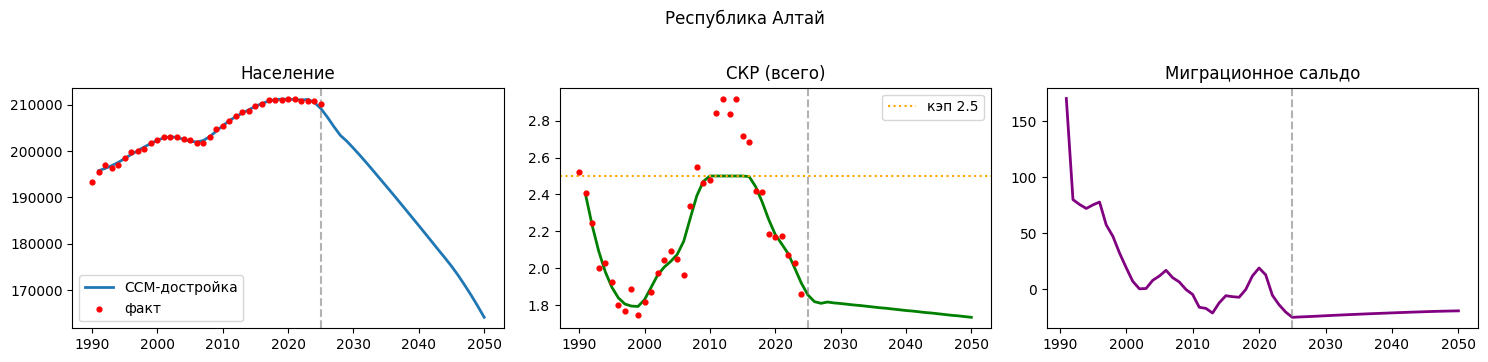

Республика Бурятия           (60, 54)  ✓ OK


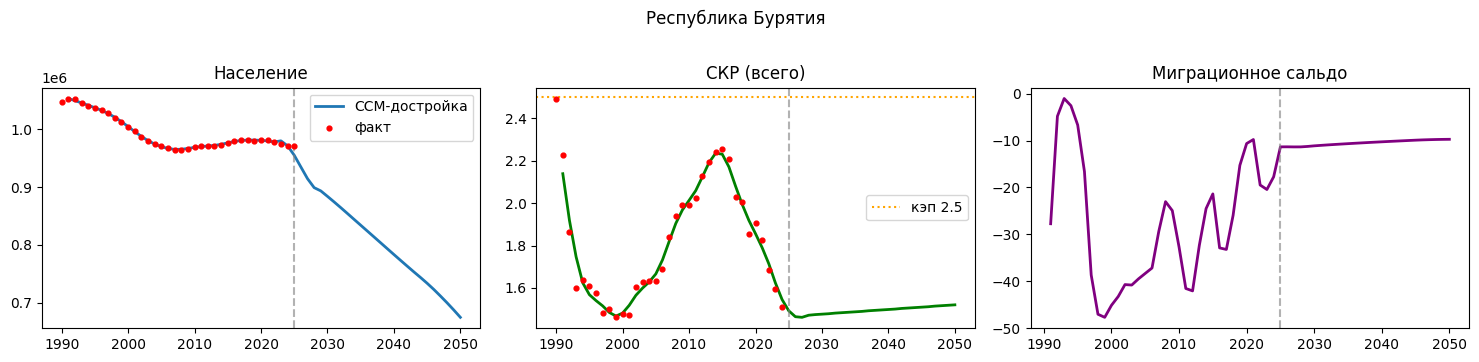

Республика Тыва              (60, 54)  ✓ OK


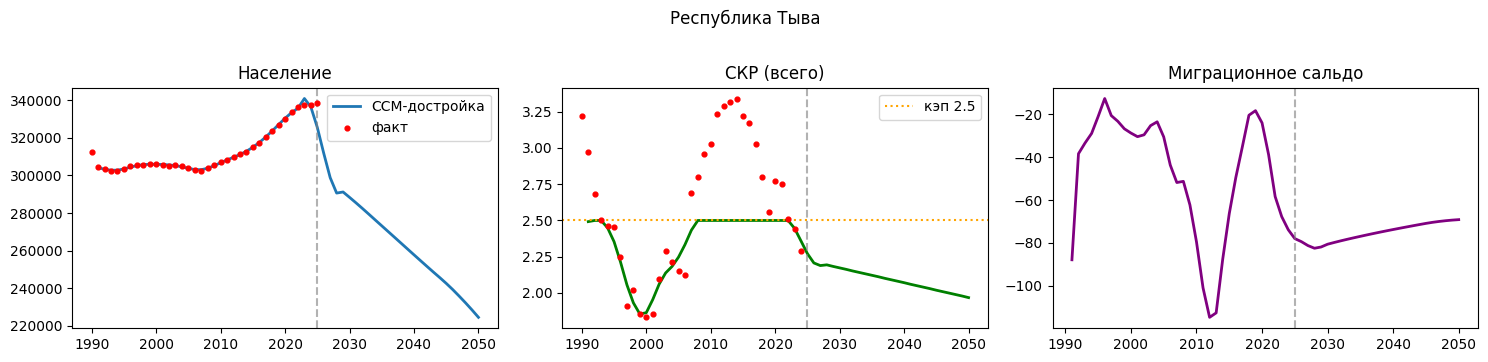

Республика Хакасия           (60, 54)  ✓ OK


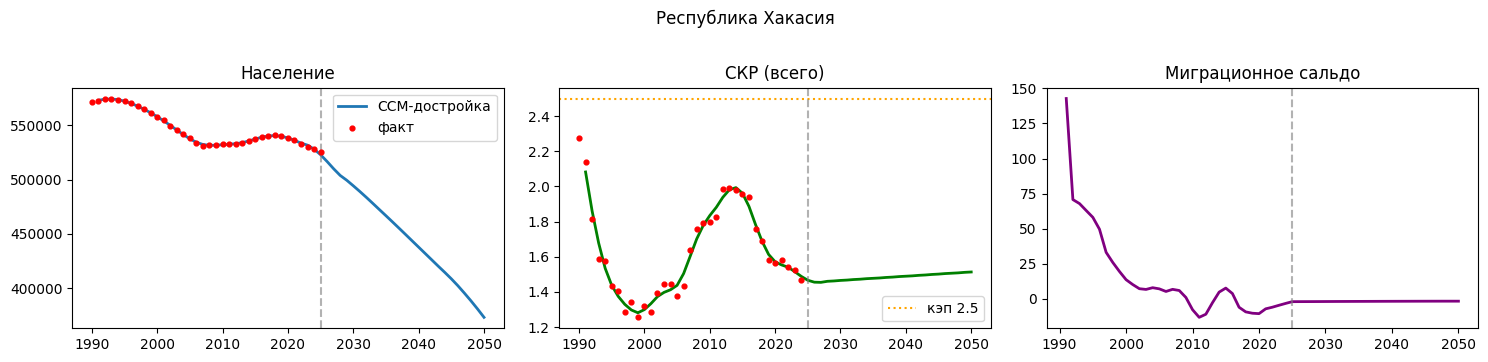

Алтайский край               (60, 54)  ✓ OK


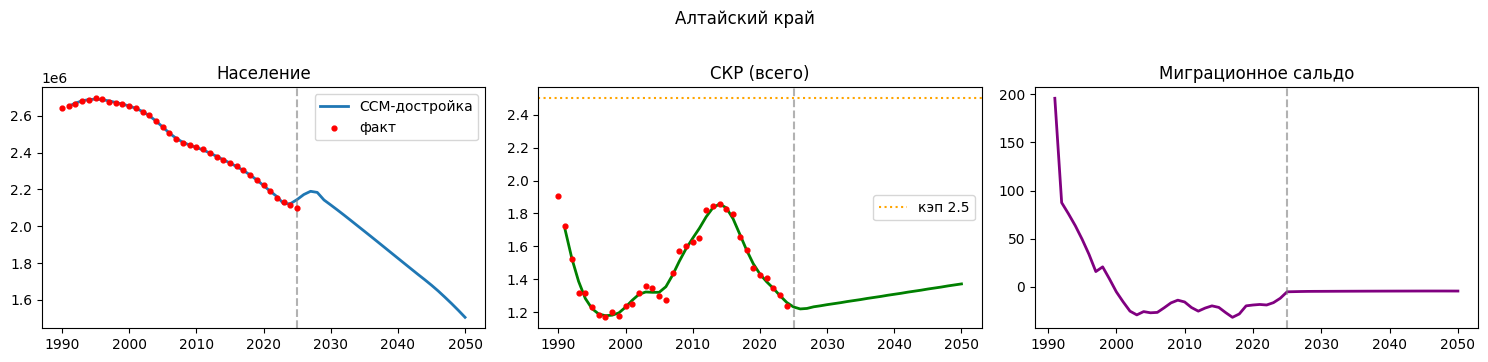

Забайкальский край           (60, 54)  ✓ OK


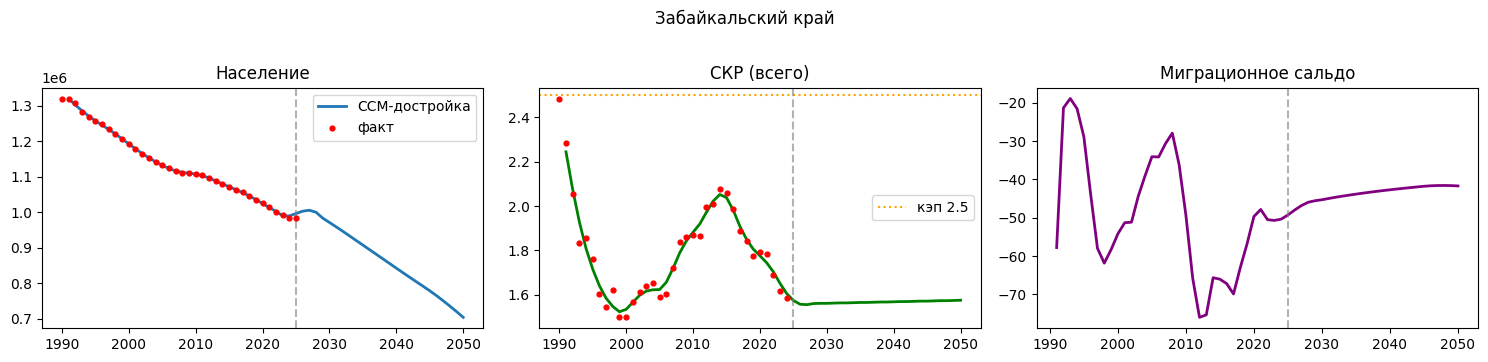

Красноярский край            (60, 54)  ✓ OK


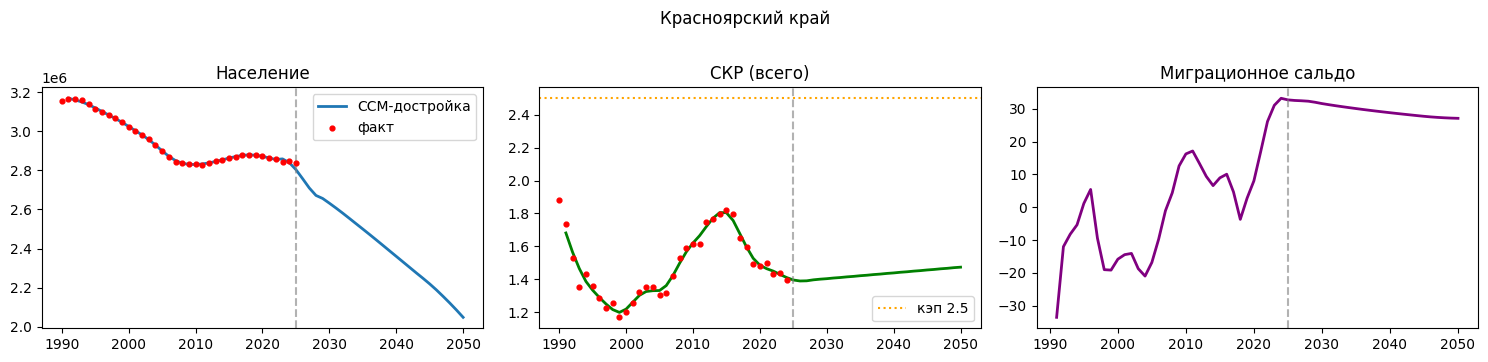

Иркутская область            (60, 54)  ✓ OK


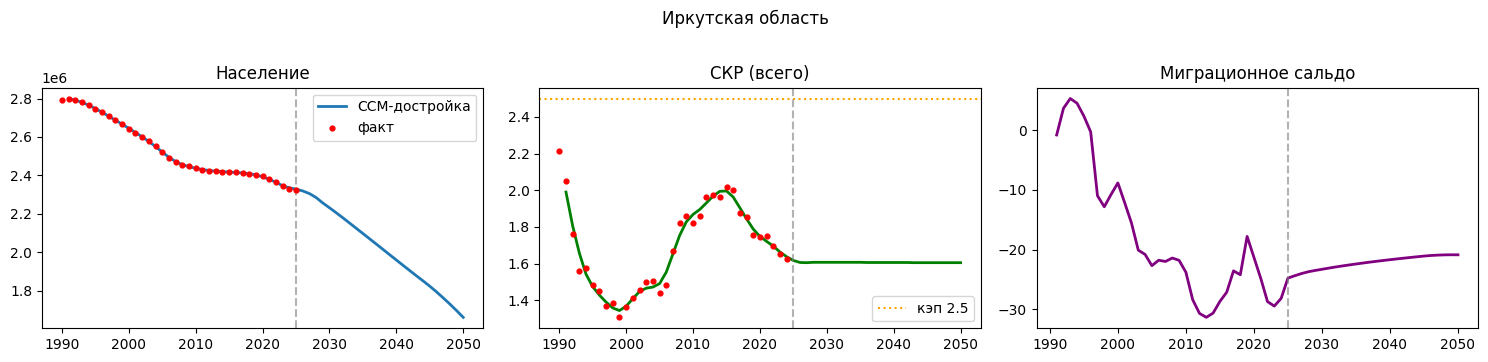

Новосибирская область        (60, 54)  ✓ OK


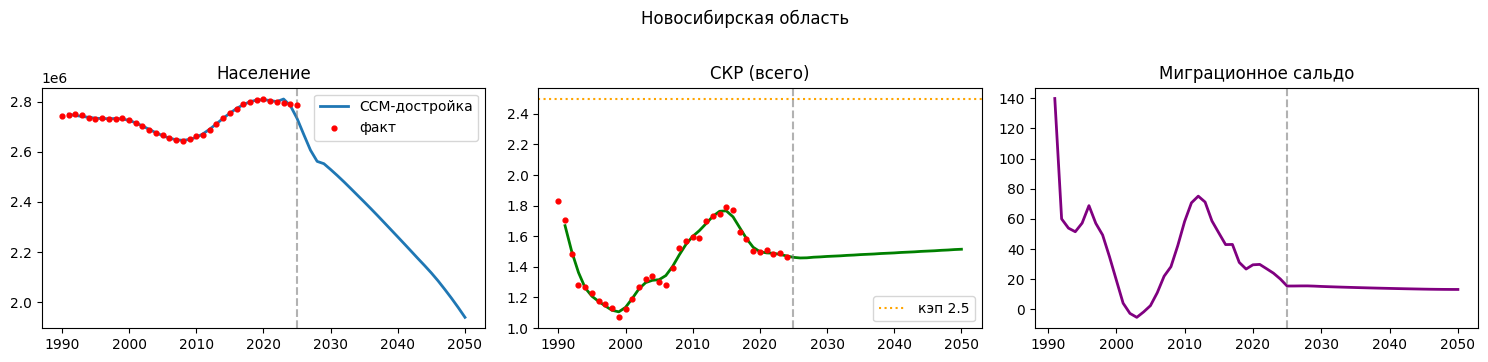


✓ Сохранён сводный файл: sfo_panels/panels_all.csv  (540, 55)

=== ИТОГОВЫЙ ОТЧЁТ ВАЛИДАТОРА ===
  Республика Алтай             (60, 54)  ✓ OK
  Республика Бурятия           (60, 54)  ✓ OK
  Республика Тыва              (60, 54)  ✓ OK
  Республика Хакасия           (60, 54)  ✓ OK
  Алтайский край               (60, 54)  ✓ OK
  Забайкальский край           (60, 54)  ✓ OK
  Красноярский край            (60, 54)  ✓ OK
  Иркутская область            (60, 54)  ✓ OK
  Новосибирская область        (60, 54)  ✓ OK


In [18]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "DejaVu Sans"

SRC = "/content/"   # папка с региональными файлами в Colab
OUT = "sfo_panels"
REGION_FILES = [
    "Республика_Алтай.xlsx", "Республика_Бурятия.xlsx", "Республика_Тыва.xlsx",
    "Республика_Хакасия.xlsx", "Алтайский_край.xlsx", "Забайкальский_край.xlsx",
    "Красноярский_край.xlsx", "Иркутская_область.xlsx", "Новосибирская_область.xlsx",
]

all_panels = []
report = []
for fn in REGION_FILES:
    path = os.path.join(SRC, fn)
    if not os.path.exists(path):
        print(f"⚠ файл не найден, пропуск: {path}"); continue
    csv_out, region, base, issues = generate_for_file(path, OUT)
    base2 = base.copy(); base2.insert(0, "Регион", region)
    all_panels.append(base2)
    status = "✓ OK" if not issues else "⚠ " + "; ".join(issues)
    report.append((region, base.shape, status))
    print(f"{region:28s} {base.shape}  {status}")

    # --- sanity-плот: население / СКР / сальдо миграции ---
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
    df_raw, _ = load_region_file(path)
    b = base.set_index("Год")
    # население
    ax[0].plot(b.index, b["Численность населения всего"], label="CCM-достройка", lw=2)
    if "Численность населения всего" in df_raw.columns:
        ax[0].scatter(df_raw.index, df_raw["Численность населения всего"], s=12, c="red", label="факт", zorder=5)
    ax[0].axvline(2025, ls="--", c="gray", alpha=0.6); ax[0].set_title("Население"); ax[0].legend()
    # СКР
    ax[1].plot(b.index, b["СКР (всего)"], lw=2, c="green")
    if "СКР (всего)" in df_raw.columns:
        ax[1].scatter(df_raw.index, df_raw["СКР (всего)"], s=12, c="red", zorder=5)
    ax[1].axhline(TFR_CAP, ls=":", c="orange", label=f"кэп {TFR_CAP}")
    ax[1].axvline(2025, ls="--", c="gray", alpha=0.6); ax[1].set_title("СКР (всего)"); ax[1].legend()
    # миграционное сальдо
    ax[2].plot(b.index, b["Миграционное сальдо"] if "Миграционное сальдо" in b else b.get("Коэффициент миграционного прироста (на 10000)"), lw=2, c="purple")
    ax[2].axvline(2025, ls="--", c="gray", alpha=0.6); ax[2].set_title("Миграционное сальдо")
    fig.suptitle(region, fontsize=12, y=1.02)
    plt.tight_layout()
    os.makedirs(OUT, exist_ok=True)
    fig.savefig(os.path.join(OUT, f"sanity_{region.replace(' ','_')}.png"), dpi=110, bbox_inches="tight")
    plt.show(); plt.close(fig)

# сводный файл
if all_panels:
    import pandas as pd
    panels_all = pd.concat(all_panels, ignore_index=True)
    panels_all.to_csv(os.path.join(OUT, "panels_all.csv"), index=False, encoding="utf-8-sig")
    print(f"\n✓ Сохранён сводный файл: {OUT}/panels_all.csv  {panels_all.shape}")
    print("\n=== ИТОГОВЫЙ ОТЧЁТ ВАЛИДАТОРА ===")
    for r, sh, st in report:
        print(f"  {r:28s} {sh}  {st}")